<a href="https://colab.research.google.com/github/ranjanashree11/AgriYield-Predictor-Forecasting-Crop-Yield-Using-Environmental-and-Soil-Data/blob/main/agriyeild_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

os.listdir("/content/drive/MyDrive/agri_project")

['ranjana infosys.xlsx',
 'X_final.csv',
 'y_final.csv',
 'scaler.pkl',
 'encoders.pkl',
 'eda_featured_data.csv',
 'final_model.pkl',
 'feature_columns.pkl']

In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/agri_project/ranjana infosys.xlsx"

df = pd.read_excel(file_path)

df.head()

,Dist Code,Year,State Code,State Name,Dist Name,Crop,Area_ha,Yield_kg_per_ha,N_req_kg_per_ha,P_req_kg_per_ha,...,Total_N_kg,Total_P_kg,Total_K_kg,Temperature_C,Humidity_%,pH,Rainfall_mm,Wind_Speed_m_s,Solar_Radiation_MJ_m2_day,Soil type
0,1,1966,14,Chhattisgarh,Durg,rice,548000.0,337.59,8.43975,4.05108,...,4624983.00,2219991.84,4069985.04,25,80,6.5,1200,2.0,18,red and yellow soil
1,1,1966,14,Chhattisgarh,Durg,maize,3000.0,666.67,18.00009,8.00004,...,54000.27,24000.12,34000.17,22,70,6.0,800,2.5,20,Red loamy soil
2,1,1966,14,Chhattisgarh,Durg,chickpea,54000.0,500.00,9.00000,5.00000,...,486000.00,270000.00,486000.00,20,60,6.5,600,1.5,16,black/clay soil
3,1,1967,14,Chhattisgarh,Durg,rice,547000.0,747.71,18.69275,8.97252,...,10224934.25,4907968.44,8997942.14,25,80,6.5,1200,2.0,18,red and yellow soil
4,1,1967,14,Chhattisgarh,Durg,maize,3000.0,1000.00,27.00000,12.00000,...,81000.00,36000.00,51000.00,22,70,6.0,800,2.5,20,Red loamy soil


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name', 'crop',
       'area_ha', 'yield_kg_per_ha', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
       'k_req_kg_per_ha', 'total_n_kg', 'total_p_kg', 'total_k_kg',
       'temperature_c', 'humidity_%', 'ph', 'rainfall_mm', 'wind_speed_m_s',
       'solar_radiation_mj_m2_day', 'soil_type'],
      dtype='object')


In [6]:
df = df.drop(columns=["dist_code", "state_code"])

In [7]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

print("✅ Missing values handled (fixed)")

✅ Missing values handled (fixed)


In [8]:
df = df.drop_duplicates()
print("✅ Duplicates removed")

✅ Duplicates removed


In [9]:
target_column = "yield_kg_per_ha"

In [10]:
features = [
    "year",
    "state_name",
    "dist_name",
    "crop",
    "soil_type",
    "temperature_c",
    "humidity_%",
    "rainfall_mm",
    "wind_speed_m_s",
    "solar_radiation_mj_m2_day",
    "ph",
    "n_req_kg_per_ha",
    "p_req_kg_per_ha",
    "total_n_kg",
    "total_p_kg",
    "total_k_kg"
]

X = df[features]
y = df[target_column]

In [11]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print("✅ Encoding completed")

✅ Encoding completed


/tmp/ipykernel_6461/642513519.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_6461/642513519.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_6461/642513519.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

In [12]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

X = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]
y = y[X.index]

print("✅ Outliers removed")
print("New shape:", X.shape)

✅ Outliers removed
New shape: (12386, 16)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Scaling done")

✅ Scaling done


In [14]:
import pickle

# Save processed dataset
X.to_csv("/content/drive/MyDrive/agri_project/X_final.csv", index=False)
y.to_csv("/content/drive/MyDrive/agri_project/y_final.csv", index=False)

# Save scaler & encoders
pickle.dump(scaler, open("/content/drive/MyDrive/agri_project/scaler.pkl", "wb"))
pickle.dump(label_encoders, open("/content/drive/MyDrive/agri_project/encoders.pkl", "wb"))

print("✅ All files saved successfully")

✅ All files saved successfully


In [15]:
X.head()

,year,state_name,dist_name,crop,soil_type,temperature_c,humidity_%,rainfall_mm,wind_speed_m_s,solar_radiation_mj_m2_day,ph,n_req_kg_per_ha,p_req_kg_per_ha,total_n_kg,total_p_kg,total_k_kg
0,-1.652939,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.238843,-0.317046,-0.591325,-0.598281,-0.606800
1,-1.652939,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.721395,-0.671826,0.031943,0.139362,0.148070
2,-1.585277,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,0.243698,0.155985,-0.552371,-0.562299,-0.578409
3,-1.585277,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.925550,-0.921991,-0.279693,-0.220467,-0.212667
4,-1.517615,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.169907,-0.249468,-0.591325,-0.598281,-0.606800


In [16]:
import os
os.listdir("/content/drive/MyDrive/agri_project")

['ranjana infosys.xlsx',
 'X_final.csv',
 'y_final.csv',
 'scaler.pkl',
 'encoders.pkl',
 'eda_featured_data.csv',
 'final_model.pkl',
 'feature_columns.pkl']

In [17]:
import pandas as pd

X = pd.read_csv("/content/drive/MyDrive/agri_project/X_final.csv")
y = pd.read_csv("/content/drive/MyDrive/agri_project/y_final.csv")

print("✅ Data Loaded")
X.head()

✅ Data Loaded


,year,state_name,dist_name,crop,soil_type,temperature_c,humidity_%,rainfall_mm,wind_speed_m_s,solar_radiation_mj_m2_day,ph,n_req_kg_per_ha,p_req_kg_per_ha,total_n_kg,total_p_kg,total_k_kg
0,-1.652939,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.238843,-0.317046,-0.591325,-0.598281,-0.606800
1,-1.652939,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.721395,-0.671826,0.031943,0.139362,0.148070
2,-1.585277,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,0.243698,0.155985,-0.552371,-0.562299,-0.578409
3,-1.585277,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.925550,-0.921991,-0.279693,-0.220467,-0.212667
4,-1.517615,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.169907,-0.249468,-0.591325,-0.598281,-0.606800


In [18]:
df = X.copy()
df["yield"] = y

df.head()

,year,state_name,dist_name,crop,soil_type,temperature_c,humidity_%,rainfall_mm,wind_speed_m_s,solar_radiation_mj_m2_day,ph,n_req_kg_per_ha,p_req_kg_per_ha,total_n_kg,total_p_kg,total_k_kg,yield
0,-1.652939,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.238843,-0.317046,-0.591325,-0.598281,-0.606800,666.67
1,-1.652939,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.721395,-0.671826,0.031943,0.139362,0.148070,500.00
2,-1.585277,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,0.243698,0.155985,-0.552371,-0.562299,-0.578409,1000.00
3,-1.585277,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.925550,-0.921991,-0.279693,-0.220467,-0.212667,288.46
4,-1.517615,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.169907,-0.249468,-0.591325,-0.598281,-0.606800,714.29


In [19]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (12386, 17)

Columns:
 Index(['year', 'state_name', 'dist_name', 'crop', 'soil_type', 'temperature_c',
       'humidity_%', 'rainfall_mm', 'wind_speed_m_s',
       'solar_radiation_mj_m2_day', 'ph', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
       'total_n_kg', 'total_p_kg', 'total_k_kg', 'yield'],
      dtype='object')


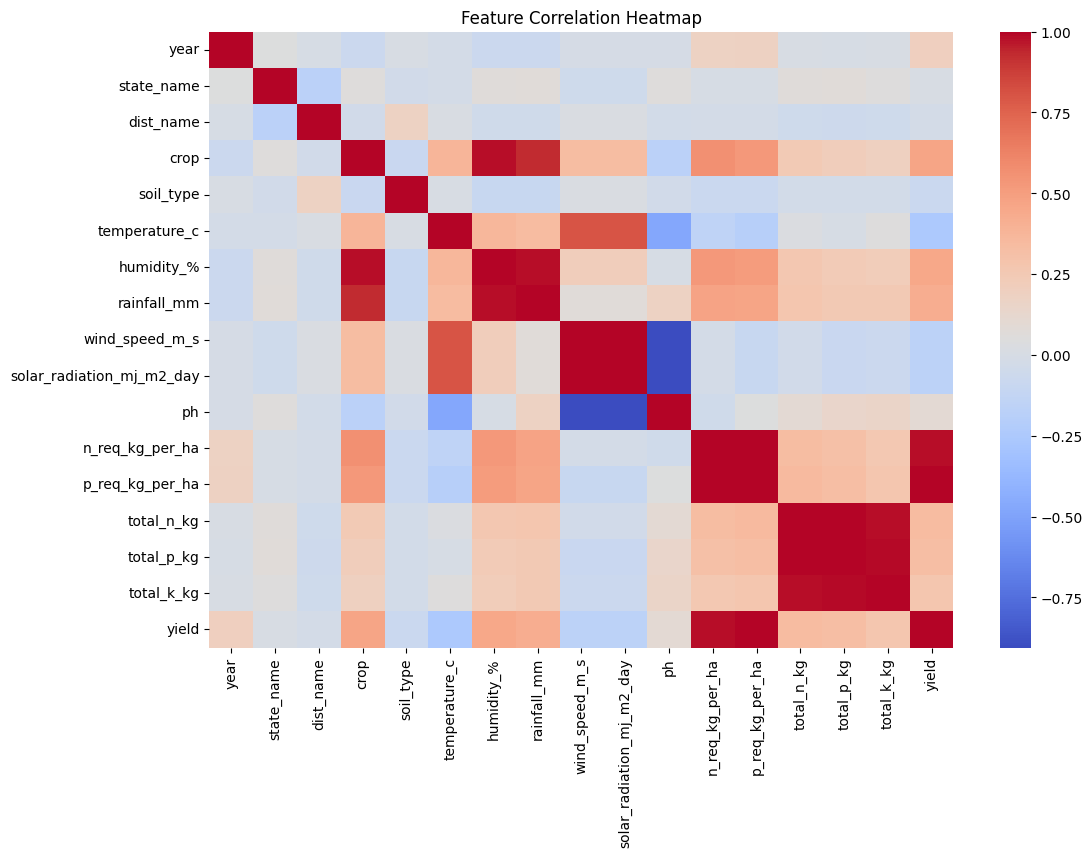

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

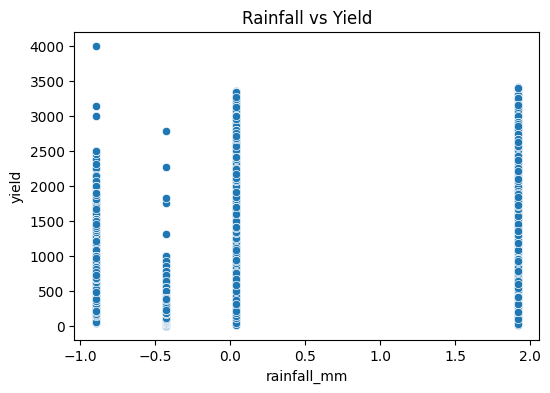

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["rainfall_mm"], y=df["yield"])
plt.title("Rainfall vs Yield")
plt.show()

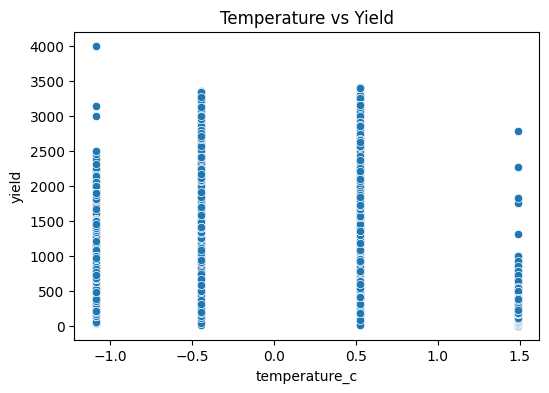

In [22]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["temperature_c"], y=df["yield"])
plt.title("Temperature vs Yield")
plt.show()

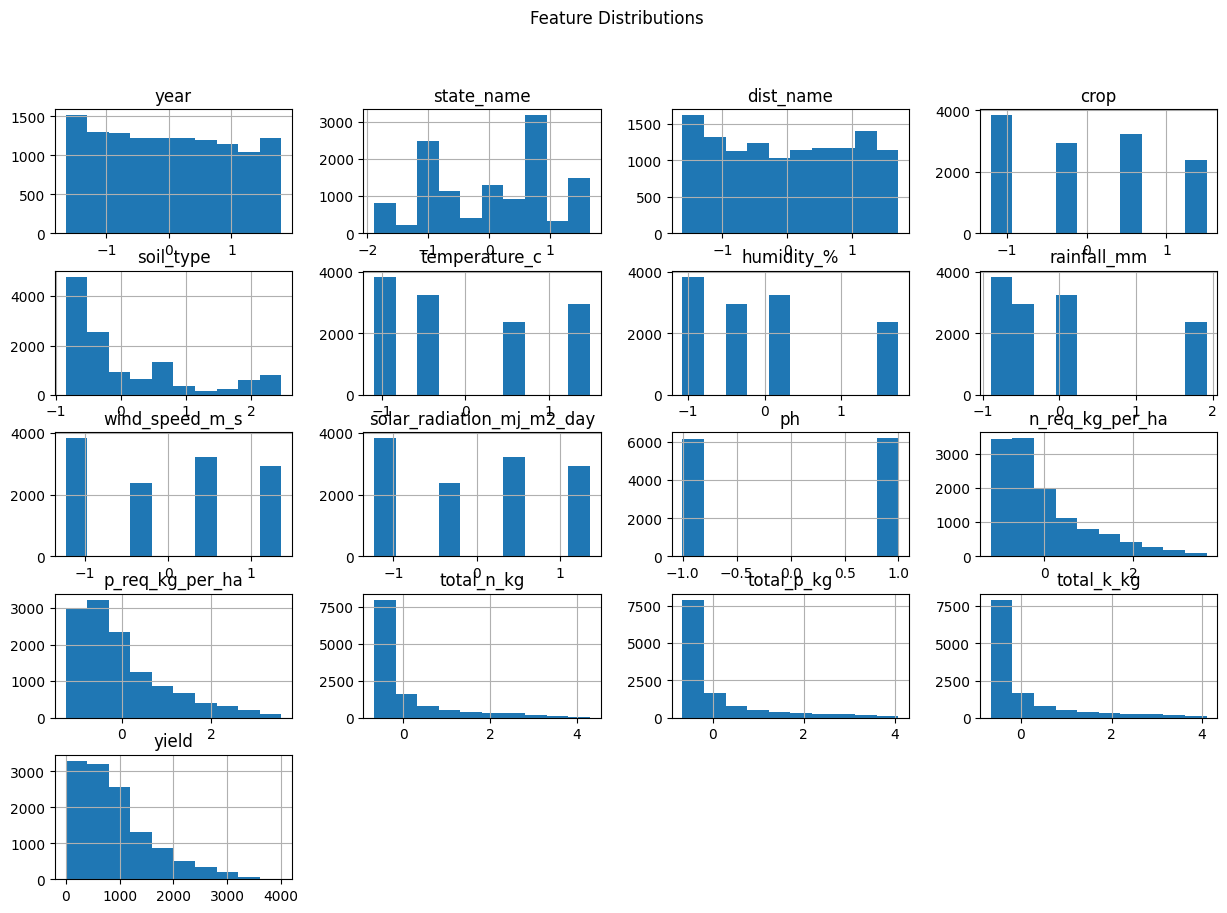

In [23]:
df.hist(figsize=(15,10))
plt.suptitle("Feature Distributions")
plt.show()

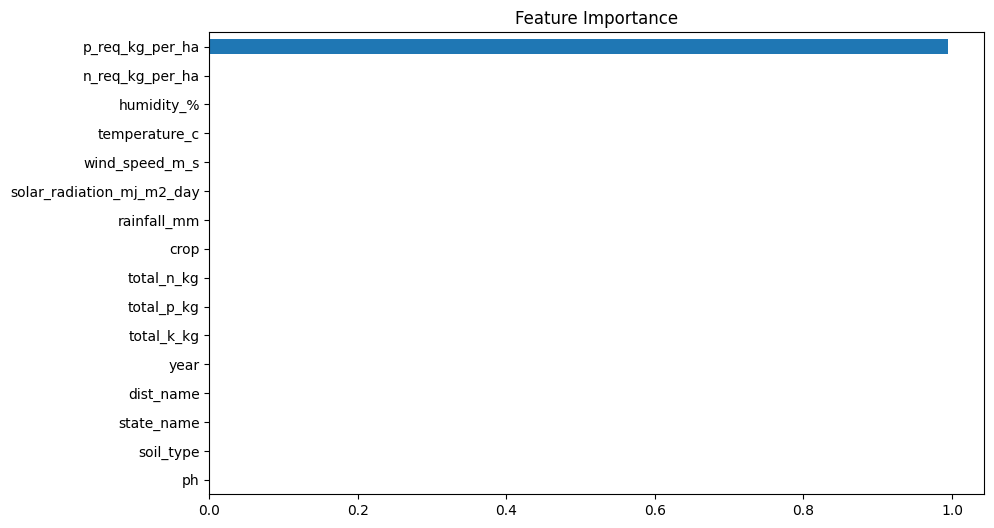

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y.values.ravel())

importance = model.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Feature Importance")
plt.show()

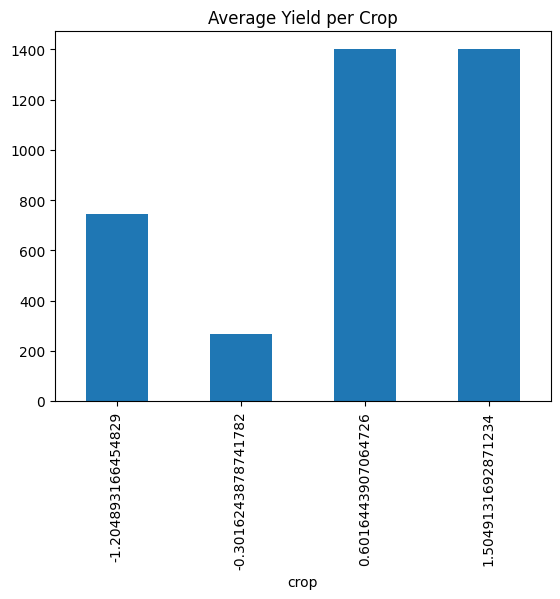

In [25]:
df.groupby("crop")["yield"].mean().plot(kind="bar")
plt.title("Average Yield per Crop")
plt.show()

In [26]:
df["temp_rain_interaction"] = df["temperature_c"] * df["rainfall_mm"]

df["humidity_temp_index"] = df["humidity_%"] * df["temperature_c"]

In [27]:
df.to_csv("/content/drive/MyDrive/agri_project/eda_featured_data.csv", index=False)

print("✅ Feature engineered data saved")

✅ Feature engineered data saved


In [28]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/agri_project/eda_featured_data.csv")

print("✅ Data Loaded")
df.head()

✅ Data Loaded


,year,state_name,dist_name,crop,soil_type,temperature_c,humidity_%,rainfall_mm,wind_speed_m_s,solar_radiation_mj_m2_day,ph,n_req_kg_per_ha,p_req_kg_per_ha,total_n_kg,total_p_kg,total_k_kg,yield,temp_rain_interaction,humidity_temp_index
0,-1.652939,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.238843,-0.317046,-0.591325,-0.598281,-0.606800,666.67,-0.019122,-0.148539
1,-1.652939,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.721395,-0.671826,0.031943,0.139362,0.148070,500.00,0.976896,1.170181
2,-1.585277,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,0.243698,0.155985,-0.552371,-0.562299,-0.578409,1000.00,-0.019122,-0.148539
3,-1.585277,-1.417666,-0.57127,-1.204893,0.758136,-1.089899,-1.07366,-0.896318,-1.231835,-1.231835,0.996776,-0.925550,-0.921991,-0.279693,-0.220467,-0.212667,288.46,0.976896,1.170181
4,-1.517615,-1.417666,-0.57127,0.601644,-0.092158,-0.444701,0.33402,0.043000,0.496278,0.496278,-1.003235,-0.169907,-0.249468,-0.591325,-0.598281,-0.606800,714.29,-0.019122,-0.148539


In [29]:
X = df.drop("yield", axis=1)
y = df["yield"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9908, 18)
Test shape: (2478, 18)


In [31]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [33]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [34]:
!pip install xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

In [35]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def evaluate(name, y_test, preds):
    print(f"\n{name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R2 Score:", r2_score(y_test, preds))

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)
evaluate("XGBoost", y_test, xgb_preds)


Linear Regression
RMSE: 17.07186077682117
MAE: 11.836268142307572
R2 Score: 0.9994326083668591

Random Forest
RMSE: 3.861548570472355
MAE: 0.5262312146892864
R2 Score: 0.999970970188883

XGBoost
RMSE: 7.280836645145332
MAE: 3.756106490965715
R2 Score: 0.9998967990295954


In [36]:
best_model = rf

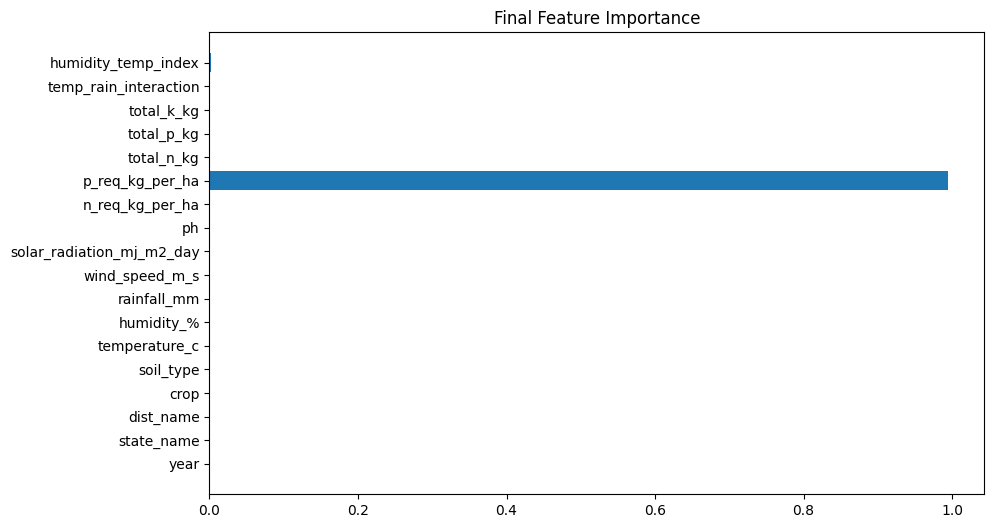

In [37]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Final Feature Importance")
plt.show()

In [38]:
import pickle

pickle.dump(best_model, open("/content/drive/MyDrive/agri_project/final_model.pkl", "wb"))

print("✅ Final model saved")

✅ Final model saved


In [39]:
import pickle

pickle.dump(best_model, open("/content/drive/MyDrive/agri_project/final_model.pkl", "wb"))
pickle.dump(list(X.columns), open("/content/drive/MyDrive/agri_project/feature_columns.pkl", "wb"))

In [40]:
!pip install gradio

In [41]:
!pip install streamlit pyngrok
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.8 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼

In [42]:
!pip install streamlit pyngrok
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
changed 22 packages in 3s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [43]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Load model files
model = pickle.load(open("/content/drive/MyDrive/agri_project/final_model.pkl", "rb"))
scaler = pickle.load(open("/content/drive/MyDrive/agri_project/scaler.pkl", "rb"))
encoders = pickle.load(open("/content/drive/MyDrive/agri_project/encoders.pkl", "rb"))
features = pickle.load(open("/content/drive/MyDrive/agri_project/feature_columns.pkl", "rb"))

# Recommendation function
def get_recommendation(pred):
    if pred < 200:
        return "⚠️ Low Yield → Improve irrigation & fertilizer"
    elif pred < 500:
        return "⚡ Moderate Yield → Optimize nutrients"
    else:
        return "✅ High Yield → Maintain current practices"

# UI
st.set_page_config(page_title="AgriYield Predictor", layout="wide")

st.title("🌾 AI AgriYield Predictor")

col1, col2, col3 = st.columns(3)

with col1:
    year = st.number_input("Year", value=2015)
    state = st.text_input("State", value="Chhattisgarh")
    district = st.text_input("District", value="Durg")
    crop = st.text_input("Crop", value="rice")
    soil = st.text_input("Soil Type", value="red and yellow soil")

with col2:
    temp = st.number_input("Temperature", value=25.0)
    humidity = st.number_input("Humidity", value=80.0)
    rainfall = st.number_input("Rainfall", value=1200.0)
    wind = st.number_input("Wind Speed", value=2.0)
    solar = st.number_input("Solar Radiation", value=18.0)

with col3:
    ph = st.number_input("pH", value=6.5)
    n = st.number_input("Nitrogen", value=8.4)
    p = st.number_input("Phosphorus", value=4.0)
    tn = st.number_input("Total N", value=4624983.0)
    tp = st.number_input("Total P", value=2219991.0)
    tk = st.number_input("Total K", value=4069985.0)

# Prediction
if st.button("🌾 Predict Yield"):

    input_dict = {
        "year": year,
        "state_name": state,
        "dist_name": district,
        "crop": crop,
        "soil_type": soil,
        "temperature_c": temp,
        "humidity_%": humidity,
        "rainfall_mm": rainfall,
        "wind_speed_m_s": wind,
        "solar_radiation_mj_m2_day": solar,
        "ph": ph,
        "n_req_kg_per_ha": n,
        "p_req_kg_per_ha": p,
        "total_n_kg": tn,
        "total_p_kg": tp,
        "total_k_kg": tk
    }

    df = pd.DataFrame([input_dict])

    # ✅ Encode categorical columns
    for col in encoders:
        df[col] = encoders[col].transform(df[col])

    # ✅ ORIGINAL FEATURES (used in scaler)
    base_features = [
        'year', 'state_name', 'dist_name', 'crop', 'soil_type',
        'temperature_c', 'humidity_%', 'rainfall_mm',
        'wind_speed_m_s', 'solar_radiation_mj_m2_day',
        'ph', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
        'total_n_kg', 'total_p_kg', 'total_k_kg'
    ]

    df_base = df[base_features]

    # ✅ Scale base features
    df_scaled = scaler.transform(df_base)
    df_scaled = pd.DataFrame(df_scaled, columns=base_features)

    # ✅ Add engineered features AFTER scaling
    df_scaled["temp_rain_interaction"] = df["temperature_c"] * df["rainfall_mm"]
    df_scaled["humidity_temp_index"] = df["humidity_%"] * df["temperature_c"]

    # ✅ Match training feature order
    df_final = df_scaled[features]

    # ✅ Predict
    prediction = model.predict(df_final)[0]
    recommendation = get_recommendation(prediction)

    st.success(f"🌾 Predicted Yield: {prediction:.2f} kg/ha")
    st.info(f"📊 Recommendation: {recommendation}")

Writing app.py


In [44]:
!streamlit run app.py &>/dev/null &

In [45]:
!streamlit run app.py &>/dev/null &

In [46]:
!curl ipv4.icanhazip.com

136.107.215.165


In [47]:
!pip install pyngrok

In [48]:
!streamlit run app.py &>/dev/null &

In [49]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-03-27T14:00:26+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-27T14:00:26+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [50]:
!ngrok config add-authtoken 3BUTp9HxMlovrL10pRivccyhsZK_3nK19cTW35n9bqrFgttNB

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [51]:
import pickle

features = pickle.load(open("/content/drive/MyDrive/agri_project/feature_columns.pkl", "rb"))
print(features)

['year', 'state_name', 'dist_name', 'crop', 'soil_type', 'temperature_c', 'humidity_%', 'rainfall_mm', 'wind_speed_m_s', 'solar_radiation_mj_m2_day', 'ph', 'n_req_kg_per_ha', 'p_req_kg_per_ha', 'total_n_kg', 'total_p_kg', 'total_k_kg', 'temp_rain_interaction', 'humidity_temp_index']


In [52]:
from pyngrok import ngrok

ngrok.kill()

In [53]:
!streamlit run app.py &>/dev/null &

In [55]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://retrorse-nella-undissemblingly.ngrok-free.dev" -> "http://localhost:8501"


In [56]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load files
model = pickle.load(open("/content/drive/MyDrive/agri_project/final_model.pkl", "rb"))
scaler = pickle.load(open("/content/drive/MyDrive/agri_project/scaler.pkl", "rb"))
encoders = pickle.load(open("/content/drive/MyDrive/agri_project/encoders.pkl", "rb"))
features = pickle.load(open("/content/drive/MyDrive/agri_project/feature_columns.pkl", "rb"))

# Recommendation
def get_recommendation(pred):
    if pred < 200:
        return "⚠️ Low Yield → Improve irrigation & fertilizer"
    elif pred < 500:
        return "⚡ Moderate Yield → Optimize nutrients"
    else:
        return "✅ High Yield → Maintain current practices"

# Page config
st.set_page_config(page_title="AgriYield Dashboard", layout="wide")

st.markdown("<h1 style='text-align:center; color:green;'>🌾 AI AgriYield Predictor</h1>", unsafe_allow_html=True)

# Dropdown values (from encoders)
state_list = list(encoders["state_name"].classes_)
district_list = list(encoders["dist_name"].classes_)
crop_list = list(encoders["crop"].classes_)
soil_list = list(encoders["soil_type"].classes_)

# Layout
col1, col2, col3 = st.columns(3)

with col1:
    year = st.number_input("Year", value=2015)
    state = st.selectbox("State", state_list)
    district = st.selectbox("District", district_list)
    crop = st.selectbox("Crop", crop_list)
    soil = st.selectbox("Soil Type", soil_list)

with col2:
    temp = st.slider("Temperature (°C)", 0.0, 50.0, 25.0)
    humidity = st.slider("Humidity (%)", 0.0, 100.0, 80.0)
    rainfall = st.slider("Rainfall (mm)", 0.0, 2000.0, 1200.0)
    wind = st.slider("Wind Speed", 0.0, 10.0, 2.0)
    solar = st.slider("Solar Radiation", 0.0, 30.0, 18.0)

with col3:
    ph = st.slider("pH", 0.0, 14.0, 6.5)
    n = st.number_input("Nitrogen", value=8.4)
    p = st.number_input("Phosphorus", value=4.0)
    tn = st.number_input("Total N", value=4624983.0)
    tp = st.number_input("Total P", value=2219991.0)
    tk = st.number_input("Total K", value=4069985.0)

# Predict
if st.button("🌾 Predict Yield"):

    input_dict = {
        "year": year,
        "state_name": state,
        "dist_name": district,
        "crop": crop,
        "soil_type": soil,
        "temperature_c": temp,
        "humidity_%": humidity,
        "rainfall_mm": rainfall,
        "wind_speed_m_s": wind,
        "solar_radiation_mj_m2_day": solar,
        "ph": ph,
        "n_req_kg_per_ha": n,
        "p_req_kg_per_ha": p,
        "total_n_kg": tn,
        "total_p_kg": tp,
        "total_k_kg": tk
    }

    df = pd.DataFrame([input_dict])

    # Encode
    for col in encoders:
        df[col] = encoders[col].transform(df[col])

    base_features = [
        'year', 'state_name', 'dist_name', 'crop', 'soil_type',
        'temperature_c', 'humidity_%', 'rainfall_mm',
        'wind_speed_m_s', 'solar_radiation_mj_m2_day',
        'ph', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
        'total_n_kg', 'total_p_kg', 'total_k_kg'
    ]

    df_base = df[base_features]

    # Scale
    df_scaled = scaler.transform(df_base)
    df_scaled = pd.DataFrame(df_scaled, columns=base_features)

    # Feature Engineering
    df_scaled["temp_rain_interaction"] = df["temperature_c"] * df["rainfall_mm"]
    df_scaled["humidity_temp_index"] = df["humidity_%"] * df["temperature_c"]

    df_final = df_scaled[features]

    prediction = model.predict(df_final)[0]
    recommendation = get_recommendation(prediction)

    # 🎉 Output
    st.success(f"🌾 Predicted Yield: {prediction:.2f} kg/ha")
    st.info(f"📊 Recommendation: {recommendation}")

    # 📊 Charts
    st.subheader("📊 Yield Analysis")

    fig, ax = plt.subplots()
    labels = ["Temperature", "Rainfall", "Humidity"]
    values = [temp, rainfall, humidity]

    ax.bar(labels, values)
    ax.set_title("Environmental Factors Impact")

    st.pyplot(fig)

    # 📄 Report
    report = f"""
    AGRIYIELD REPORT

    Yield: {prediction:.2f} kg/ha

    State: {state}
    District: {district}
    Crop: {crop}

    Recommendation:
    {recommendation}
    """

    st.download_button("📄 Download Report", report, file_name="agri_report.txt")

Overwriting app.py


In [57]:
!streamlit run app.py &>/dev/null &

In [58]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://retrorse-nella-undissemblingly.ngrok-free.dev" -> "http://localhost:8501"


In [59]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load files
model = pickle.load(open("/content/drive/MyDrive/agri_project/final_model.pkl", "rb"))
scaler = pickle.load(open("/content/drive/MyDrive/agri_project/scaler.pkl", "rb"))
encoders = pickle.load(open("/content/drive/MyDrive/agri_project/encoders.pkl", "rb"))
features = pickle.load(open("/content/drive/MyDrive/agri_project/feature_columns.pkl", "rb"))

# ✅ Initialize history
if "history" not in st.session_state:
    st.session_state.history = []

# Recommendation
def get_recommendation(pred):
    if pred < 200:
        return "⚠️ Low Yield → Improve irrigation & fertilizer"
    elif pred < 500:
        return "⚡ Moderate Yield → Optimize nutrients"
    else:
        return "✅ High Yield → Maintain current practices"

# Page config
st.set_page_config(page_title="AgriYield Dashboard", layout="wide")

st.markdown("<h1 style='text-align:center; color:green;'>🌾 AI AgriYield Predictor</h1>", unsafe_allow_html=True)

# Dropdown values
state_list = list(encoders["state_name"].classes_)
district_list = list(encoders["dist_name"].classes_)
crop_list = list(encoders["crop"].classes_)
soil_list = list(encoders["soil_type"].classes_)

# Layout
col1, col2, col3 = st.columns(3)

with col1:
    year = st.number_input("Year", value=2015)
    state = st.selectbox("State", state_list)
    district = st.selectbox("District", district_list)
    crop = st.selectbox("Crop", crop_list)
    soil = st.selectbox("Soil Type", soil_list)

with col2:
    temp = st.slider("Temperature (°C)", 0.0, 50.0, 25.0)
    humidity = st.slider("Humidity (%)", 0.0, 100.0, 80.0)
    rainfall = st.slider("Rainfall (mm)", 0.0, 2000.0, 1200.0)
    wind = st.slider("Wind Speed", 0.0, 10.0, 2.0)
    solar = st.slider("Solar Radiation", 0.0, 30.0, 18.0)

with col3:
    ph = st.slider("pH", 0.0, 14.0, 6.5)
    n = st.number_input("Nitrogen", value=8.4)
    p = st.number_input("Phosphorus", value=4.0)
    tn = st.number_input("Total N", value=4624983.0)
    tp = st.number_input("Total P", value=2219991.0)
    tk = st.number_input("Total K", value=4069985.0)

# Predict
if st.button("🌾 Predict Yield"):

    input_dict = {
        "year": year,
        "state_name": state,
        "dist_name": district,
        "crop": crop,
        "soil_type": soil,
        "temperature_c": temp,
        "humidity_%": humidity,
        "rainfall_mm": rainfall,
        "wind_speed_m_s": wind,
        "solar_radiation_mj_m2_day": solar,
        "ph": ph,
        "n_req_kg_per_ha": n,
        "p_req_kg_per_ha": p,
        "total_n_kg": tn,
        "total_p_kg": tp,
        "total_k_kg": tk
    }

    df = pd.DataFrame([input_dict])

    # Encode
    for col in encoders:
        df[col] = encoders[col].transform(df[col])

    base_features = [
        'year', 'state_name', 'dist_name', 'crop', 'soil_type',
        'temperature_c', 'humidity_%', 'rainfall_mm',
        'wind_speed_m_s', 'solar_radiation_mj_m2_day',
        'ph', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
        'total_n_kg', 'total_p_kg', 'total_k_kg'
    ]

    df_base = df[base_features]

    # Scale
    df_scaled = scaler.transform(df_base)
    df_scaled = pd.DataFrame(df_scaled, columns=base_features)

    # Feature Engineering
    df_scaled["temp_rain_interaction"] = df["temperature_c"] * df["rainfall_mm"]
    df_scaled["humidity_temp_index"] = df["humidity_%"] * df["temperature_c"]

    df_final = df_scaled[features]

    prediction = model.predict(df_final)[0]
    recommendation = get_recommendation(prediction)

    # ✅ Save history
    history_entry = {
        "State": state,
        "District": district,
        "Crop": crop,
        "Yield": round(prediction, 2)
    }
    st.session_state.history.append(history_entry)

    # Output
    st.success(f"🌾 Predicted Yield: {prediction:.2f} kg/ha")
    st.info(f"📊 Recommendation: {recommendation}")

    # Chart
    st.subheader("📊 Environmental Impact")

    fig, ax = plt.subplots()
    labels = ["Temperature", "Rainfall", "Humidity"]
    values = [temp, rainfall, humidity]

    ax.bar(labels, values, color=["orange", "blue", "green"])
    ax.set_title("Environmental Factors")

    st.pyplot(fig)

    # Report
    report = f"""
    AGRIYIELD REPORT

    Yield: {prediction:.2f} kg/ha

    State: {state}
    District: {district}
    Crop: {crop}

    Recommendation:
    {recommendation}
    """

    st.download_button("📄 Download Report", report, file_name="agri_report.txt")

# ✅ HISTORY SECTION (OUTSIDE BUTTON)
st.subheader("📜 Prediction History")

if st.session_state.history:
    history_df = pd.DataFrame(st.session_state.history)
    st.dataframe(history_df)

    # Download history
    csv = history_df.to_csv(index=False).encode("utf-8")
    st.download_button("⬇️ Download History", csv, "history.csv")

    # Clear history
    if st.button("🗑️ Clear History"):
        st.session_state.history = []
        st.success("History Cleared!")

    # Graph
    st.subheader("📈 Yield Trend")

    history_df["Index"] = range(1, len(history_df) + 1)

    fig2, ax2 = plt.subplots()
    ax2.plot(history_df["Index"], history_df["Yield"], marker='o', color='green')
    ax2.fill_between(history_df["Index"], history_df["Yield"], color='lightgreen', alpha=0.5)

    ax2.set_xlabel("Prediction Number")
    ax2.set_ylabel("Yield")
    ax2.set_title("Prediction Trend")

    st.pyplot(fig2)

else:
    st.write("No history yet")

Overwriting app.py


In [60]:
!streamlit run app.py &>/dev/null &

In [61]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://retrorse-nella-undissemblingly.ngrok-free.dev" -> "http://localhost:8501"


In [62]:

!git init
!git config --global user.email "gowdaranjuu011@gmail.com"
!git config --global user.name "Ranjanashree H A"

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [63]:
!git init
!git branch -m main
!git config --global init.defaultBranch main

Reinitialized existing Git repository in /content/.git/


In [64]:
!git branch

In [65]:
!git branch -m main

In [66]:
!mkdir -p /content/AgriYieldProject
!cp app.py /content/AgriYieldProject/
!cp -r sample_data/ /content/AgriYieldProject/

In [67]:
%cd /content/AgriYieldProject

/content/AgriYieldProject


In [68]:
!git init
!git branch -m main
!git add .
!git commit -m "Initial commit"
!git remote add origin https://github.com/gowdaranjuu/Agriyield--Predictor.git
!git push -u origin main

Initialized empty Git repository in /content/AgriYieldProject/.git/
[main (root-commit) a0e2922] Initial commit
 7 files changed, 50256 insertions(+)
 create mode 100644 app.py
 create mode 100755 sample_data/README.md
 create mode 100755 sample_data/anscombe.json
 create mode 100644 sample_data/california_housing_test.csv
 create mode 100644 sample_data/california_housing_train.csv
 create mode 100644 sample_data/mnist_test.csv
 create mode 100644 sample_data/mnist_train_small.csv
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!git remote -v

In [69]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load files
model = pickle.load(open("/content/drive/MyDrive/agri_project/final_model.pkl", "rb"))
scaler = pickle.load(open("/content/drive/MyDrive/agri_project/scaler.pkl", "rb"))
encoders = pickle.load(open("/content/drive/MyDrive/agri_project/encoders.pkl", "rb"))
features = pickle.load(open("/content/drive/MyDrive/agri_project/feature_columns.pkl", "rb"))

# Initialize history
if "history" not in st.session_state:
    st.session_state.history = []

# Recommendation
def get_recommendation(pred):
    if pred < 200:
        return "⚠️ Low Yield → Improve irrigation & fertilizer"
    elif pred < 500:
        return "⚡ Moderate Yield → Optimize nutrients"
    else:
        return "✅ High Yield → Maintain current practices"

# Page config
st.set_page_config(page_title="AgriYield Dashboard", layout="wide")

st.markdown("<h1 style='text-align:center; color:green;'>🌾 AI AgriYield Predictor</h1>", unsafe_allow_html=True)

# Dropdown values
state_list = list(encoders["state_name"].classes_)
district_list = list(encoders["dist_name"].classes_)
crop_list = list(encoders["crop"].classes_)
soil_list = list(encoders["soil_type"].classes_)

# Layout
col1, col2, col3 = st.columns(3)

with col1:
    year = st.number_input("Year", value=2015)
    state = st.selectbox("State", state_list)
    district = st.selectbox("District", district_list)
    crop = st.selectbox("Crop", crop_list)
    soil = st.selectbox("Soil Type", soil_list)

with col2:
    temp = st.slider("Temperature (°C)", 0.0, 50.0, 25.0)
    humidity = st.slider("Humidity (%)", 0.0, 100.0, 80.0)
    rainfall = st.slider("Rainfall (mm)", 0.0, 2000.0, 1200.0)
    wind = st.slider("Wind Speed (m/s)", 0.0, 10.0, 2.0)
    solar = st.slider("Solar Radiation (MJ/m²/day)", 0.0, 30.0, 18.0)

with col3:
    ph = st.slider("pH", 0.0, 14.0, 6.5)

    # ✅ Don’t know NPK checkbox
    unknown_npk = st.checkbox("I don't know N, P, K / total nutrients (Auto-fill)")

    if unknown_npk:
        # Fill default or average values (can customize based on crop/soil)
        n = 10.0
        p = 5.0
        tn = 4000000.0
        tp = 2200000.0
        tk = 4000000.0
        st.info("Using default NPK values for prediction")
    else:
        n = st.number_input("Nitrogen (kg/ha)", value=8.4)
        p = st.number_input("Phosphorus (kg/ha)", value=4.0)
        tn = st.number_input("Total N", value=4624983.0)
        tp = st.number_input("Total P", value=2219991.0)
        tk = st.number_input("Total K", value=4069985.0)

# Predict
if st.button("🌾 Predict Yield"):
    input_dict = {
        "year": year,
        "state_name": state,
        "dist_name": district,
        "crop": crop,
        "soil_type": soil,
        "temperature_c": temp,
        "humidity_%": humidity,
        "rainfall_mm": rainfall,
        "wind_speed_m_s": wind,
        "solar_radiation_mj_m2_day": solar,
        "ph": ph,
        "n_req_kg_per_ha": n,
        "p_req_kg_per_ha": p,
        "total_n_kg": tn,
        "total_p_kg": tp,
        "total_k_kg": tk
    }

    df = pd.DataFrame([input_dict])

    # Encode
    for col in encoders:
        df[col] = encoders[col].transform(df[col])

    base_features = [
        'year', 'state_name', 'dist_name', 'crop', 'soil_type',
        'temperature_c', 'humidity_%', 'rainfall_mm',
        'wind_speed_m_s', 'solar_radiation_mj_m2_day',
        'ph', 'n_req_kg_per_ha', 'p_req_kg_per_ha',
        'total_n_kg', 'total_p_kg', 'total_k_kg'
    ]

    df_base = df[base_features]

    # Scale
    df_scaled = scaler.transform(df_base)
    df_scaled = pd.DataFrame(df_scaled, columns=base_features)

    # Feature Engineering
    df_scaled["temp_rain_interaction"] = df["temperature_c"] * df["rainfall_mm"]
    df_scaled["humidity_temp_index"] = df["humidity_%"] * df["temperature_c"]

    df_final = df_scaled[features]

    prediction = model.predict(df_final)[0]
    recommendation = get_recommendation(prediction)

    # Save history
    history_entry = {
        "State": state,
        "District": district,
        "Crop": crop,
        "Yield": round(prediction, 2),
        "NPK Known": not unknown_npk
    }
    st.session_state.history.append(history_entry)

    # Output
    st.success(f"🌾 Predicted Yield: {prediction:.2f} kg/ha")
    st.info(f"📊 Recommendation: {recommendation}")

    # Environmental chart
    st.subheader("📊 Environmental Impact")
    fig, ax = plt.subplots()
    labels = ["Temperature", "Rainfall", "Humidity"]
    values = [temp, rainfall, humidity]
    ax.bar(labels, values, color=["orange", "blue", "green"])
    ax.set_title("Environmental Factors")
    st.pyplot(fig)

    # Report
    report = f"""
    AGRIYIELD REPORT

    Yield: {prediction:.2f} kg/ha

    State: {state}
    District: {district}
    Crop: {crop}

    Recommendation:
    {recommendation}

    NPK values used: {'Default/Estimated' if unknown_npk else 'Farmer Provided'}
    """
    st.download_button("📄 Download Report", report, file_name="agri_report.txt")

# HISTORY SECTION
st.subheader("📜 Prediction History")
if st.session_state.history:
    history_df = pd.DataFrame(st.session_state.history)
    st.dataframe(history_df)
    csv = history_df.to_csv(index=False).encode("utf-8")
    st.download_button("⬇️ Download History", csv, "history.csv")

    if st.button("🗑️ Clear History"):
        st.session_state.history = []
        st.success("History Cleared!")

    # Yield trend chart
    st.subheader("📈 Yield Trend")
    history_df["Index"] = range(1, len(history_df) + 1)
    fig2, ax2 = plt.subplots()
    ax2.plot(history_df["Index"], history_df["Yield"], marker='o', color='green')
    ax2.fill_between(history_df["Index"], history_df["Yield"], color='lightgreen', alpha=0.5)
    ax2.set_xlabel("Prediction Number")
    ax2.set_ylabel("Yield")
    ax2.set_title("Prediction Trend")
    st.pyplot(fig2)
else:
    st.write("No history yet")

Overwriting app.py


In [70]:
!streamlit run app.py &>/dev/null &

In [71]:
from pyngrok import ngrok
ngrok.kill()
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://retrorse-nella-undissemblingly.ngrok-free.dev" -> "http://localhost:8501"
